<a href="https://colab.research.google.com/github/zccarver001-gif/WiDS-University-Datathon-2026/blob/main/2026UniversityDatathon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data loaded and merged: (14743, 22)
Target count:
High_Alert_Activity
0    7018
1    6943
Name: count, dtype: int64

Model Comparison:
                           Model  Accuracy    Recall  Precision  F1 Score
0  Logistic Regression + Bagging  0.541470  0.572293   0.536592  0.553868
1                  Decision Tree  0.782553  0.733583   0.811146  0.770417
2                  Random Forest  0.785131  0.733295   0.816026  0.772451

Best model: Decision Tree

Classification Report:
                      precision    recall  f1-score   support

Lower Alert Activity       0.76      0.83      0.79      3509
 High Alert Activity       0.81      0.73      0.77      3472

            accuracy                           0.78      6981
           macro avg       0.79      0.78      0.78      6981
        weighted avg       0.79      0.78      0.78      6981



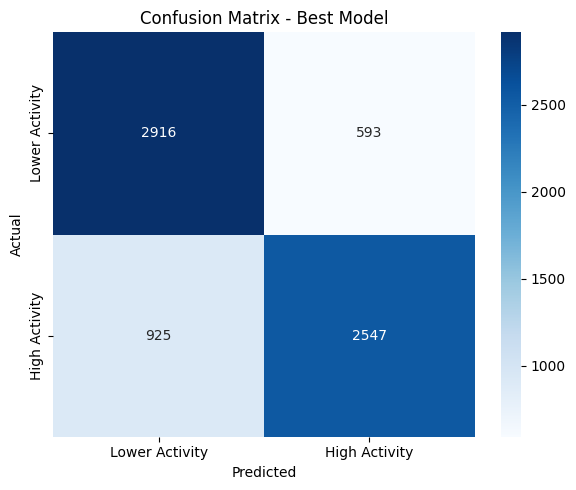


Top 10 Unique Locations:
 geo_event_id  number_of_alert_records  Activity_Probability                     date_created Risk_Level
        51796                        4                   1.0 2025-06-17 00:27:39.716343+00:00  Huge Risk
        25171                       63                   1.0 2025-06-03 19:40:29.102237+00:00  Huge Risk
        25339                      123                   1.0 2025-06-30 11:31:49.971152+00:00  Huge Risk
        51791                       18                   1.0 2025-06-16 22:31:09.342217+00:00  Huge Risk
        57147                       28                   1.0 2025-07-26 23:56:34.403032+00:00  Huge Risk
        58778                      224                   1.0 2025-07-18 18:23:48.874814+00:00  Huge Risk
        58643                        7                   1.0 2025-08-05 02:09:10.797557+00:00  Huge Risk
        58471                      251                   1.0 2025-08-06 03:45:50.841287+00:00  Huge Risk
        58374                

In [ ]:
# Track 1: Accelerating Equitable Evacuations
# My goal is to find areas that may need faster evacuation alerts and better spread

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix, classification_report


# Part 1: Load and merge files

# I load the three files and combine them into one dataset
# All the information is important for the output

df1 = pd.read_csv("evac_zone_status_geo_event_map.csv")
df2 = pd.read_csv("evac_zones_gis_evaczone.csv")
df3 = pd.read_csv("evac_zones_gis_evaczonechangelog.csv")

df = pd.merge(df1, df2, on="uid_v2", how="left")
df = pd.merge(df, df3, left_on="id", right_on="evac_zone_id", how="left")

print("Data loaded and merged:", df.shape)


# Part 2: Prepare data

# I clean the date column and create time features that the model can use

df["date_created"] = pd.to_datetime(df["date_created"], errors="coerce")
df = df.dropna(subset=["date_created", "geo_event_id"])

df["hour"] = df["date_created"].dt.hour
df["day"] = df["date_created"].dt.day
df["month"] = df["date_created"].dt.month
df["day_of_week"] = df["date_created"].dt.dayofweek

# I count how many records each geo event has
# This is used as a simple way to measure alert activity

df["geo_event_count"] = df.groupby("geo_event_id")["geo_event_id"].transform("count")

# I create the target variable
# 1 means high alert activity
# 0 means lower alert activity

median_count = df["geo_event_count"].median()
df["High_Alert_Activity"] = (df["geo_event_count"] > median_count).astype(int)

print("Target count:")
print(df["High_Alert_Activity"].value_counts())


# Part 3: Features, checking for the missing values, and scaling

# I use time features to predict if an area has high alert activity
# I do not use geo_event_count as a feature because it was used to create the target

features = ["hour", "day", "month", "day_of_week"]

X = df[features]
y = df["High_Alert_Activity"]

# I fill missing values using the median
# Method used to fill the missing values: Simple Imputer
X = SimpleImputer(strategy="median").fit_transform(X)

# I scale the numbers so they are all between 0 and 1.
X = MinMaxScaler().fit_transform(X)

# I split the data into training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.5,
    random_state=42,
    stratify=y
)

# Part 4: Test the models Grid Search

# I am comparing the three models to see which one performs the best
# Also I am trying to find the best parameters

models = {
    "Logistic Regression + Bagging": {
        "model": BaggingClassifier(
            estimator=LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=22
            ),
            random_state=22
        ),
        "params": {
            "n_estimators": [50, 100],
            "max_samples": [0.7, 1.0],
            "max_features": [0.7, 1.0]
        }
    },

    "Decision Tree": {
        "model": DecisionTreeClassifier(
            class_weight="balanced",
            random_state=22
        ),
        "params": {
            "max_depth": [3, 5, 10, None],
            "min_samples_split": [2, 5, 10]
        }
    },

    "Random Forest": {
        "model": RandomForestClassifier(
            class_weight="balanced",
            random_state=22
        ),
        "params": {
            "n_estimators": [50, 100],
            "max_depth": [5, 10, None],
            "min_samples_split": [2, 5]
        }
    }
}

results = []
best_model = None
best_name = ""
best_recall = -1

for name, item in models.items():
    grid = GridSearchCV(
        item["model"],
        item["params"],
        scoring="recall",
        cv=3,
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    model = grid.best_estimator_
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    pre = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([name, acc, rec, pre, f1, grid.best_params_])

    if rec > best_recall:
        best_recall = rec
        best_model = model
        best_name = name

results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Recall", "Precision", "F1 Score", "Best Parameters"]
)

print()
print("Model Comparison:")
print(results_df[["Model", "Accuracy", "Recall", "Precision", "F1 Score"]])

print()
print("Best model:", best_name)


# Part 5: Confusion matrix for best model

# Checking how well the best model predicted lower activity and high activity

y_pred_best = best_model.predict(X_test)

print()
print("Classification Report:")
print(classification_report(
    y_test,
    y_pred_best,
    target_names=["Lower Alert Activity", "High Alert Activity"]
))

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Lower Activity", "High Activity"],
    yticklabels=["Lower Activity", "High Activity"]
)

plt.title("Confusion Matrix - Best Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# Putting a confusion matrix to see how well my model is performing

# Part 6: Predict risk for all records

# Best model to predict the activity risk for every record
df["Predicted_High_Activity"] = best_model.predict(X)
df["Activity_Probability"] = best_model.predict_proba(X)[:, 1]


# This function turns the probability into an easy risk label

def risk_level(prob):
    if prob >= 0.70:
        return "Huge Risk"
    elif prob >= 0.40:
        return "Medium Risk"
    else:
        return "Low Risk"


df["Risk_Level"] = df["Activity_Probability"].apply(risk_level)


# Part 7: Top 10 locations

# I group by geo_event_id so the same location does not repeat many times

location_risk = df.groupby("geo_event_id").agg({
    "geo_event_count": "max",
    "Activity_Probability": "max",
    "date_created": "min"
}).reset_index()

# Trying to rename the column to make it easier to understand
location_risk = location_risk.rename(columns={
    "geo_event_count": "number_of_alert_records"
})

# I calculate the risk level again after grouping the locations.
location_risk["Risk_Level"] = location_risk["Activity_Probability"].apply(risk_level)

top10 = location_risk.sort_values("Activity_Probability", ascending=False).head(10)

print()
print("Top 10 Unique Locations:")
print(top10.to_string(index=False))


# Part 8: Recommendation and messages

# These functions create the action plan and alert messages

def recommendation(risk):
    if risk == "Huge Risk":
        return "Send alert now through SMS, app, radio, and social media. Prioritize vulnerable households."
    elif risk == "Medium Risk":
        return "Prepare evacuation warning, monitor updates, and notify local agencies."
    else:
        return "Continue monitoring and prepare alert templates."


def english_message(geo_id, risk):
    if risk == "Huge Risk":
        return f"WILDFIRE EVACUATION ALERT: Area {geo_id}. Risk is HUGE. Leave now if ordered. Take medicine, documents, pets, and chargers."
    elif risk == "Medium Risk":
        return f"WILDFIRE WARNING: Area {geo_id}. Risk is MEDIUM. Prepare to evacuate and watch official updates."
    else:
        return f"WILDFIRE UPDATE: Area {geo_id}. Risk is LOW. Continue monitoring official updates."

# To add something interesting I add messages for english and Spanish

def spanish_message(geo_id, risk):
    if risk == "Huge Risk":
        return f"ALERTA DE EVACUACIÓN: Área {geo_id}. Riesgo MUY ALTO. Salga ahora si hay orden. Lleve medicinas, documentos, mascotas y cargadores."
    elif risk == "Medium Risk":
        return f"ADVERTENCIA DE INCENDIO: Área {geo_id}. Riesgo MEDIO. Prepárese para evacuar y revise actualizaciones oficiales."
    else:
        return f"ACTUALIZACIÓN DE INCENDIO: Área {geo_id}. Riesgo BAJO. Siga monitoreando información oficial."

# Adding the recommendation and messages to the top 10 table.

top10["Recommendation"] = top10["Risk_Level"].apply(recommendation)

top10["English_Message"] = top10.apply(
    lambda row: english_message(row["geo_event_id"], row["Risk_Level"]),
    axis=1
)

top10["Spanish_Message"] = top10.apply(
    lambda row: spanish_message(row["geo_event_id"], row["Risk_Level"]),
    axis=1
)

# I print one example for the highest-risk location.

example = top10.iloc[0]

print()
print("Recommendation for Highest-Risk Location:")
print("Best model used:", best_name)
print("Geo Event ID:", example["geo_event_id"])
print("Risk:", example["Risk_Level"])
print("Alert records:", example["number_of_alert_records"])
print("Action:", example["Recommendation"])
print("English:", example["English_Message"])
print("Spanish:", example["Spanish_Message"])


# Part 9: Save results

# I save the full results, the top 10 locations, and the model comparison

df.to_csv("track1_all_alert_activity_results.csv", index=False)
top10.to_csv("track1_top10_locations_with_messages.csv", index=False)
results_df.to_csv("track1_model_comparison.csv", index=False)

print()
print("Saved results")